# Homework: "Karen"

More Pandas, but this time tackling a sociolinguistic issue: the recent prominence, especially a few years ago, of the stereotype "Karen".

The woman's name Karen, which was previously entirely unremarkable, has over the past few years become understood to pejoratively reference a specific social type: an entitled and officious white woman, typically with short-ish blonde hair, middle-aged, who imperiously demands to "speak with the manager".

This stereotype sits in a somewhat complicated social position.  On the one hand, "Karens" are frequently mocked for their entitled attitude, so the use of the term tends to signal a generally egalitarian stance.  On the other hand, the stereotype itself has also been argued to have [sexist overtones](https://www.latimes.com/opinion/story/2020-05-23/column-karen-meme-white-women-behaving-badly): why hold a woman's name up for mockery in this connection, and not a man's?   This has led a number of people to ask: what is the male version of "Karen"?

Unhappily for me, someone has argued that the male version of "Karen" is "Terry".  

And this isn't just speculation - there is actual data backing it up.  It turns out that the [frequency profiles over historical time](https://www.reddit.com/r/dataisbeautiful/comments/i9ljw9/i_analysed_70_years_of_baby_names_in_the_us_to/) of the names "Karen" and "Terry" in the US are quite similar in shape.  The data are from the US Social Security Administration, specifically their [Popular Baby Names dataset](https://www.ssa.gov/oact/babynames/limits.html), which covers the years 1880-2018.  I have downloaded the data and included it in this homework folder.

Your homework assignment is to attempt to replicate this finding, examine its assumptions, and consider other ways of exploring the same data under other assumptions, in order to answer the question: what is the male version of "Karen"?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

In [2]:
# we start by creating a df, reading in all SSA baby-name data, and loading it into that df.
# insert YOB = year of birth as new column in df.  we will need this.
df = pd.DataFrame()
for year in range(1880,2018+1):
    indf = pd.read_csv("data/yob"+str(year)+".txt",names=['Name','Sex','Count'])
    indf['YOB'] = year
    df = pd.concat([df, indf], ignore_index=True)
df

,Name,Sex,Count,YOB
0,Mary,F,7065,1880
1,Anna,F,2604,1880
2,Emma,F,2003,1880
3,Elizabeth,F,1939,1880
4,Minnie,F,1746,1880
...,...,...,...,...
1957041,Zylas,M,5,2018
1957042,Zyran,M,5,2018
1957043,Zyrie,M,5,2018
1957044,Zyron,M,5,2018


In [3]:
# that takes a while, but the result is a df of length 1,957,046.
# now let's get some basic descriptive statistics.
# the apply stuff is to suppress scientific notation:
# https://stackoverflow.com/questions/40347689/dataframe-describe-suppress-scientific-notation#47207283
df.describe().apply(lambda s: s.apply(lambda x: format(x, 'g')))

,Count,YOB
count,1.95705e+06,1.95705e+06
mean,179.686,1975.56
std,1522.8,34.1912
min,5,1880
25%,7,1952
50%,12,1985
75%,32,2004
max,99689,2018


### Attempt to replicate the original finding.

The original finding plotted, for both "Karen" and "Terry", the number of births per year in the US as a percent of peak popularity.

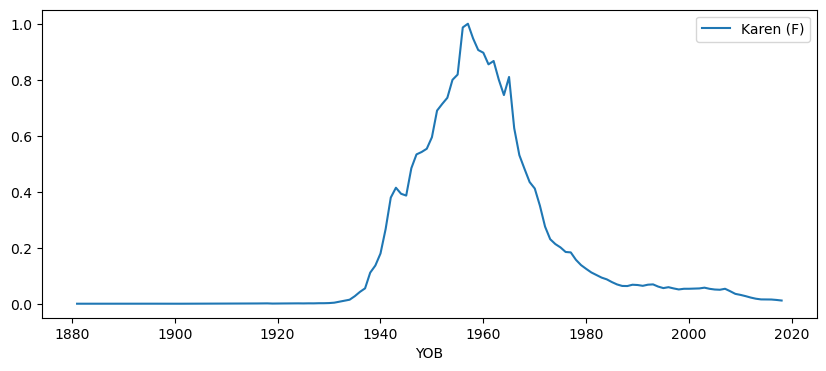

In [4]:
# first plot just Karen.
# NB: Karen is sometimes used as a man's name - filter those out, and focus on Karen as a woman's name only.
# NB: i am making a COPY so that kdf can be munged independently of df.
# otherwise you get a warning about updating a derivative of a df.
kdf = df[(df.Name=='Karen') & (df.Sex=='F')].copy()
k_peak = kdf.Count.max()  # peak popularity.
kdf['ScaledCount'] = kdf.Count / k_peak  # number of births as percent of peak popularity.
kdf.plot(kind='line',x='YOB',y='ScaledCount',label='Karen (F)', figsize=(10,4))
plt.show()

---
**2 points for the following cell**

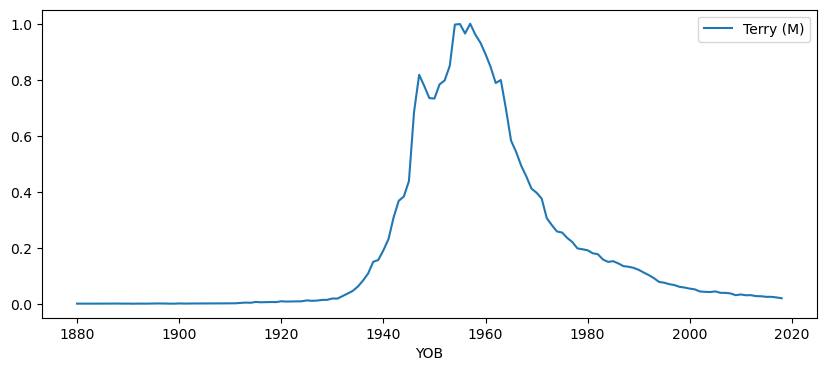

In [5]:
# now analogously plot just Terry, as a man's name.  
# Terry is sometimes a woman's name, but we focus here only on Terry as a man's name.

# YOUR CODE GOES HERE.
dfMT = df[(df.Name=='Terry') & (df.Sex=='M')].copy()

# Repurposing the code chunk from above
MTerryPeak = dfMT.Count.max()  # peak popularity.
dfMT['ScaledCount'] = dfMT.Count / MTerryPeak  # number of births as percent of peak popularity.
dfMT.plot(kind='line',x='YOB',y='ScaledCount',label='Terry (M)', figsize=(10,4))
plt.show()

---
**2 points for the following cell**

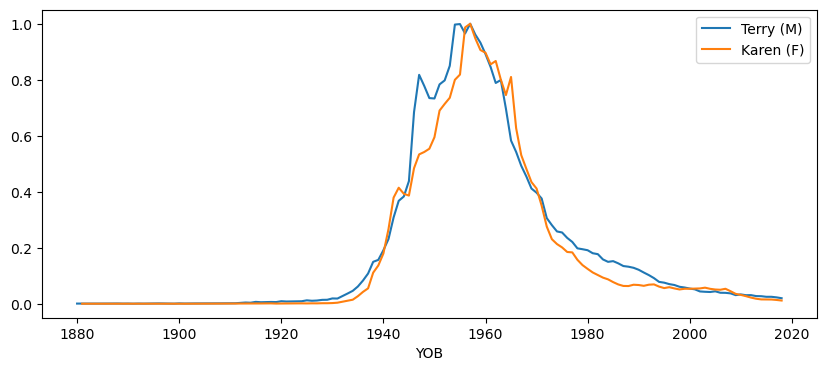

In [6]:
# now plot both names together (Karen (F) and Terry (M)), in a single graph, over all years in the dataset.

# YOUR CODE GOES HERE.
ax = plt.gca()  # get current axes for the two plots to share.

dfMT.plot(kind='line',x='YOB',y='ScaledCount',label='Terry (M)', figsize=(10,4), ax = ax)
kdf.plot(kind='line',x='YOB',y='ScaledCount',label='Karen (F)', figsize=(10,4), ax = ax)
plt.show()

---
**2 points for the following cell**

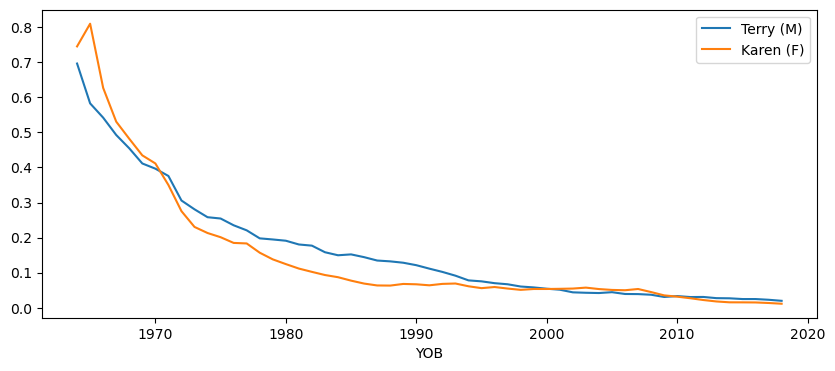

In [7]:
# now plot names both together, but only the recent past, as in the reddit post.  This means from 1946 onward.

NewMT = dfMT[dfMT.YOB >= 1964].copy()
NewFK = kdf[kdf.YOB >= 1964].copy()
ax = plt.gca()
NewMT.plot(kind='line',x='YOB',y='ScaledCount',label='Terry (M)', figsize=(10,4), ax = ax)
NewFK.plot(kind='line',x='YOB',y='ScaledCount',label='Karen (F)', figsize=(10,4), ax = ax)
plt.show()

### Interim observations

What can you conclude from your findings above?  Have you at least qualitatively replicated the original finding from the Reddit post?

There seems to be a similar trend in the names Terry and Karen, with both peaking at about the same time, around 1955, at a similar level of popularity proportional to their peak, and a similar steepness in rise and then decline before and after its peak. Looking at the graph, there's some qualitative evidence that Terry could be the male equivalent of Karen.

### Extension

There are at least 2 questions left open by the analysis above.

- The data were plotted as a percent of peak popularity.  This means any difference in overall popularity of names is ignored, and we get a normalized profile that necessarily peaks at 1.0.  How would the results of the analysis change if we were to instead consider raw counts, rather than counts as a percent of peak popularity?
- Are there other male names that fit the Karen curve more closely?  The Reddit post suggests (but doesn't actually say) that Terry fits more closely than other male names.  Let's find out - and we can do so for both ways of considering the data: percent of peak popularity, and raw counts.

---
**2 points for the following cell**

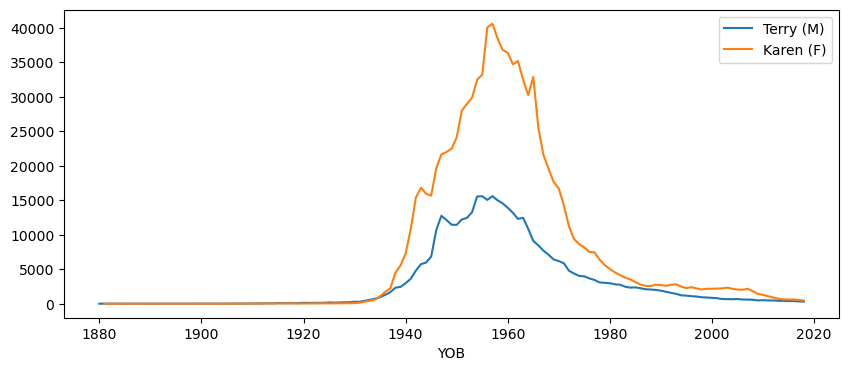

In [8]:
# let's start by plotting raw counts, for Karen (F) and Terry (M), over all years, in a single plot.

# YOUR CODE GOES HERE.
ax = plt.gca()  # get current axes for the two plots to share.

dfMT.plot(kind='line',x='YOB',y='Count',label='Terry (M)', figsize=(10,4), ax = ax)
kdf.plot(kind='line',x='YOB',y='Count',label='Karen (F)', figsize=(10,4), ax = ax)
plt.show()

However well or poorly Terry aligns with Karen in terms of raw counts, it might align better with Karen than any other male name does.  Is that the case?  Let's find out.

To do that, we will:
- Pull together all male names.
- Notice that there are lots of them.
- Sort them by frequency to focus on the top 100.
- Reassure ourselves that Terry is in that much smaller set.  
- Compare the profile of each male name in that smaller set with the profile of Karen, and find the best match.

We want a smaller set just to keep the amount of computation reasonable.

I have done this for you, to set you up for the next step, below.

In [9]:
# start by getting all names for men.
names_male = df[df.Sex=='M'].Name.unique() # 41,475
print("There are", len(names_male), "names for men in the dataset.")

There are 41475 names for men in the dataset.


In [10]:
# that's a lot of names!  let's see if we can get away with considering only the top 100 or so.
# group by names, restricting attn to men for now.
grouped = df[df.Sex=='M'].groupby('Name')
# find out how often each name was used overall.
counts = grouped.Count.sum()
print(type(counts))
counts

<class 'pandas.core.series.Series'>


Name
Aaban     114
Aabid      16
Aabir      10
Aadam     273
Aadan     130
         ... 
Zyus       11
Zyvion      5
Zyvon       7
Zyyon       6
Zzyzx      10
Name: Count, Length: 41475, dtype: int64

In [11]:
# now sort names by popularity
s = counts.sort_values(ascending=False)
s

Name
James       5164280
John        5124817
Robert      4820129
Michael     4362731
William     4117369
             ...   
Georden           5
Masiya            5
Masonlee          5
Geore             5
Geovan            5
Name: Count, Length: 41475, dtype: int64

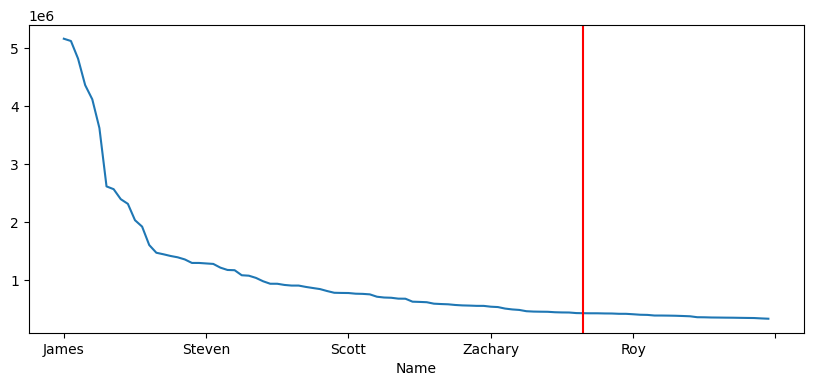

In [12]:
# and now finally plot, showing Terry relative to other names.
ax = s[:100].plot(kind='line', figsize=(10,4))
# find what number 'Terry' is in this sequence.
ix = s.index.to_list().index('Terry')
ax.axvline(ix,color='red')  # draw vertical line.
plt.show()

In [13]:
# since Terry is in the top 100 male names, and Karen is more popular than Terry, we're probably
# safe considering only the top 100 male names.
sorted_male_names = s[:100].index.to_list()
print("Top 10 male names:\n", sorted_male_names[:10])

Top 10 male names:
 ['James', 'John', 'Robert', 'Michael', 'William', 'David', 'Joseph', 'Richard', 'Charles', 'Thomas']


In [14]:
# get Karen raw counts profile.  we include YOB bc we can't assume Karen exists for each year.
# and we set YOB to be the index
k = kdf[['YOB','Count']].set_index('YOB')
k

,Count
YOB,
1881,6
1885,10
1886,9
1887,9
1888,5
...,...
2014,631
2015,626
2016,615


In [15]:
# some years could be missing - and in fact some are!  
# so let's re-index, using the full set of years, and assign 0 for years that are missing in the data.
kk = k.reindex(range(1880,2018+1),fill_value=0)
kk

,Count
YOB,
1880,0
1881,6
1882,0
1883,0
1884,0
...,...
2014,631
2015,626
2016,615


---
**8 points for the following cell**:
 - 1 point for using the right count measure (scaled vs unscaled)
 - 1 point for prepping male names correctly
 - 3 points for computing MSE (mean squared error) between each male name and Karen
 - 3 points for finding the male name that is best aligned with Karen, assessed by MSE

In [16]:
# now cycle through male names, analogously filling in blank years for each of them.
# and then find MSE of each to karen counts over time.
# and find the male name that is best aligned with Karen, judging by raw frequency counts (unscaled).

best_MSE = None
best_name = ""
for name in sorted_male_names:
    newdf = df[(df.Name==name) & (df.Sex=='M')].copy()
    new = newdf[['YOB','Count']].set_index('YOB')
    newnew = new.reindex(range(1880,2018+1),fill_value=0)
    sums = pd.DataFrame()
    sums['Difference'] = newnew['Count'] - kk['Count']
    sums['SquaredDifference'] = sums['Difference'] * sums['Difference']
    totalDifference = sum(sums['SquaredDifference'])
    MSE = totalDifference / len(kk)
    if not best_MSE or best_MSE > MSE:
        best_name = name
        best_MSE = MSE
    
#     # YOUR CODE GOES HERE.  
best_aligned = best_name   # YOUR CODE GOES HERE.
# print("Best aligned with Karen, by MSE, raw counts:", best_aligned)

In [17]:
print("Best aligned with Karen, by MSE, raw counts:", best_aligned)
print(best_MSE)

Best aligned with Karen, by MSE, raw counts: Gary
21461540.56115108


---
**2 points for the following cell**

<Axes: xlabel='YOB'>

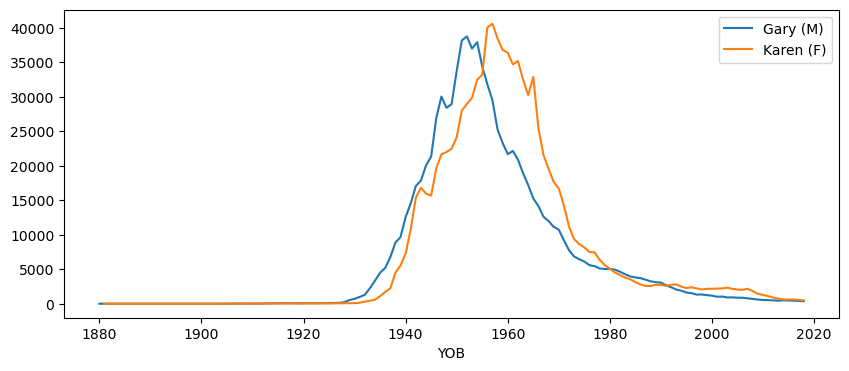

In [18]:
# plot frequencies for mr. best_aligned relative to Karen, based on raw counts, across all years in the dataset, in a single plot with two lines.

# YOUR CODE GOES HERE.
dfGary = df[(df.Name=='Gary') & (df.Sex=='M')].copy()
ax = plt.gca()  # get current axes for the two plots to share.

dfGary.plot(kind='line',x='YOB',y='Count',label='Gary (M)', figsize=(10,4), ax = ax)
kdf.plot(kind='line',x='YOB',y='Count',label='Karen (F)', figsize=(10,4), ax = ax)


---
**8 points for the following cell**:
 - 1 point for using the right count measure (scaled vs unscaled)
 - 1 point for prepping male names correctly
 - 3 points for computing MSE (mean squared error) between each male name and Karen
 - 3 points for finding the male name that is best aligned with Karen, assessed by MSE

In [19]:
# now do the same thing but for scaled counts: which male name best matches Karen by that measure, rather than by raw counts?
# cycle through male names, and find MSE of each to karen scaled counts over time - and find the male name best aligned with Karen.

kk_peak = kk.Count.max()
kk['ScaledCount'] = kk.Count / kk_peak

best_MSE = None
best_name = ""

for name in sorted_male_names:
    newdf = df[(df.Name==name) & (df.Sex=='M')].copy()
    new = newdf[['YOB','Count']].set_index('YOB')
    newnew = new.reindex(range(1880,2018+1),fill_value=0)
    new_peak = newnew.Count.max()  # peak popularity.
    newnew['ScaledCount'] = newnew.Count / new_peak  # number of births as percent of peak popularity.
    sums = pd.DataFrame()
    sums['Difference'] = newnew['ScaledCount'] - kk['ScaledCount']
    sums['SquaredDifference'] = sums['Difference'] * sums['Difference']
    totalDifference = sum(sums['SquaredDifference'])
    MSE = totalDifference / len(kk)
    if not best_MSE or best_MSE > MSE:
        best_name = name
        best_MSE = MSE
    # YOUR CODE GOES HERE.  
best_aligned = best_name   # YOUR CODE GOES HERE.
print("Best aligned with Karen, by MSE, scaled counts:", best_aligned)

Best aligned with Karen, by MSE, scaled counts: Terry


---
**2 points for the following cell**

<Axes: xlabel='YOB'>

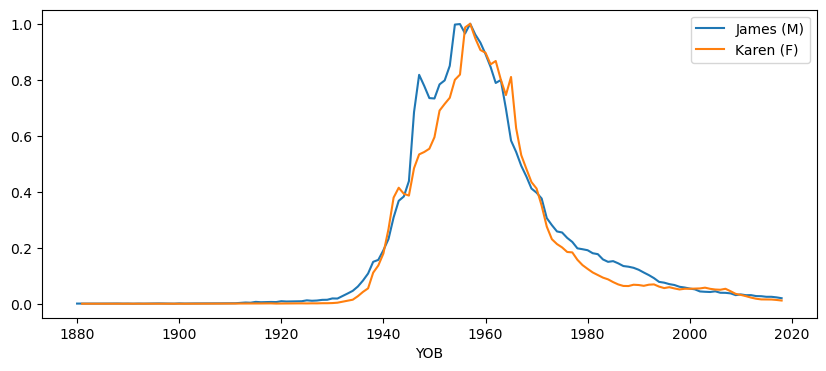

In [20]:
# plot frequencies for mr. best_aligned relative to Karen, based on scaled counts, across all years in the dataset, in a single plot with two lines.

# YOUR CODE GOES HERE.
# Deja vu here...
dfTerry = df[(df.Name=='Terry') & (df.Sex=='M')].copy()

T_peak = dfTerry.Count.max()  # peak popularity.
dfTerry['ScaledCount'] = dfTerry.Count / T_peak  # number of births as percent of peak popularity.

ax = plt.gca()  # get current axes for the two plots to share.

dfTerry.plot(kind='line',x='YOB',y='ScaledCount',label='James (M)', figsize=(10,4), ax = ax)
kdf.plot(kind='line',x='YOB',y='ScaledCount',label='Karen (F)', figsize=(10,4), ax = ax)

---
**2 points for the following cell, on observations.**

### Concluding observations

Say a few brief words here about:
 - what you can conclude from the analyses above,
 - what the limitations are of these analyses,
 - how you might extend what has already been done to get a better analysis, and
 - what data you would need to do that.


From the analysis above, we can conclude that, in this dataset, the name used most similarly to Karen in terms of total use and the time most commonly used was Gary. By proportion and time used, the name used most similarly was, in fact, Terry. We cannot conclude any kind of behavioral data about Karens, Terrys, or Garys from this data, or any similarities between people with these names (except, of course, that on average Karens, Terrys, and Garys will all be about the same age). 
I think an interesting direction to extend this analysis would be to look at how the term Karen originated. An interesting way to do that would be to look at social media posts that use the tag "Karen" and see what other tags they have, and track what tags most commonly go with "Karen" over time. We can use these trends to find the male name that gets used with the same tags most often. This would be an estimation of the male equivalent of a "Karen," not by looking at naming conventions, but by estimating the social definition of the term Karen online. We would need a collection of posts and their tags for many years, probably from 2000 to the present. It would be interesting to have this information for multiple social media sites, and compare behavior on Reddit to that on Instagram or TikTok.

---
**1 point for the following cell, on extensions - but that point will be awarded only if you are not already at full credit.**

### Further extensions (optional)

 - What women's names other than Karen could well have been selected by society instead of Karen, assuming that the selection is driven largely by age, which is determined by the frequency profile of a name over time?
 - For some other target name NAME that you care about - i.e. some target name NAME other than Karen - what names other than NAME align maximally with NAME?  
 - If you find yourself able to pursue any of the possibilities for extension that you may have listed under "Concluding observations" above, by all means feel free!
 - Etc.

# Grading

**Score**: 27/30

Good job overall! Code runs smoothly.

You missed 2 points because in cell 7 you used "ScaledCounts" instead of Counts. This doesn't match the Reddit post.
I also substracted a point because you didn't realize that the color lines/tags in the Reddit plot and the ones you show are different.

The rest looks good!:)

IP